Pandas:
       Pandas library offers data structures and operations  to manipulate and analyse data . It is the best library for statistical work.

Statistics:
           It is a field of mathematics that deals with collection , presentation , interpretation  , analysis and organization .

Descriptive statistics:
                        it is a type of statistics used to summarize and describe the main features of dataset.
                    e.g. mean,median,mode,standard deviation,variance,range,tables,graphs,charts etc

Inferential Statistics :
                        It is the branch of statistics that deals with making conclusions and predictions of population based on sampling. e.g. hypothesis testing, z test ,p test ,correlation,regression .                    


In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility purpose 
np.random.seed(42)

n=50

# Create a DataFrame with random numbers
students = np.random.choice(['Graduate', 'Undergraduate'], size=n)
genders = np.random.choice(['Male' , 'Female'] , size=n)
universities = np.random.choice(['UoA', 'UoC', 'UoW'], size=n)
marks = np.random.normal(loc=60 , scale = 20 ,size = n)

# insert outliers
out_idx=np.random.choice(n , size=3 , replace=False)
marks[out_idx] = [130 , -20 ,200]

# Create admission status based on random choice
admission=np.where( np.random.rand(n)>0.5 , 'Yes' , 'No')

# Create DataFrame
df = pd.DataFrame({
    'Students' : students,
    'Gender' : genders ,
    'University' : universities,
    'Marks' : marks,
    'Admission' : admission

})

# Randomly introduce missing values 

for col in df.columns:
    missing_count = int(0.07 * n)
    missing_indices = np.random.choice(df.index, size=missing_count, replace=False)
    df.loc[missing_indices, col] = np.nan


print(df.head())






        Students  Gender University      Marks Admission
0       Graduate    Male        UoW  83.594327       NaN
1  Undergraduate  Female        UoC  42.035841        No
2       Graduate     NaN        UoC  76.695908       Yes
3       Graduate  Female        UoC  65.931228       Yes
4       Graduate    Male        UoC  39.243402       Yes


In [2]:
df.columns

Index(['Students', 'Gender', 'University', 'Marks', 'Admission'], dtype='object')

In [3]:
df.tail()

,Students,Gender,University,Marks,Admission
45,Undergraduate,Female,UoC,88.079175,No
46,Undergraduate,Female,UoA,59.628984,Yes
47,Graduate,Female,UoW,26.529908,Yes
48,Undergraduate,Female,UoW,38.549363,Yes
49,Undergraduate,Male,UoC,40.148276,No


In [4]:
df.info

<bound method DataFrame.info of          Students  Gender University       Marks Admission
0        Graduate    Male        UoW   83.594327       NaN
1   Undergraduate  Female        UoC   42.035841        No
2        Graduate     NaN        UoC   76.695908       Yes
3        Graduate  Female        UoC   65.931228       Yes
4        Graduate    Male        UoC   39.243402       Yes
5   Undergraduate  Female        UoC         NaN       Yes
6        Graduate  Female        UoC         NaN        No
7        Graduate    Male        UoW  -20.000000       Yes
8        Graduate    Male        UoW   89.908685       Yes
9   Undergraduate    Male        NaN   66.763625        No
10       Graduate    Male        UoW  127.445925        No
11       Graduate    Male        UoA   41.592184       Yes
12       Graduate    Male        UoC   52.027232       Yes
13       Graduate    Male        UoA   58.782718        No
14  Undergraduate    Male        UoA   31.624991       Yes
15       Graduate  Femal

In [5]:
df.describe()

,Marks
count,47.000000
mean,61.686706
std,33.265236
min,-20.000000
25%,43.125337
50%,58.782718
75%,74.168368
max,200.000000


In [6]:
df.isnull()

,Students,Gender,University,Marks,Admission
0,False,False,False,False,True
1,False,False,False,False,False
2,False,True,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,False,True,False
6,False,False,False,True,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,False,True,False,False


In [7]:
df.isnull().sum()

Students      3
Gender        3
University    3
Marks         3
Admission     3
dtype: int64

In [8]:
df.isnull().sum().sum()

np.int64(15)

In [9]:
data_clean=df.dropna(subset =['Marks','Admission' , 'Students'])

In [10]:
data_clean.isnull().sum()

Students      0
Gender        3
University    2
Marks         0
Admission     0
dtype: int64

In [11]:
data_clean.describe()

,Marks
count,41.000000
mean,61.300809
std,34.632643
min,-20.000000
25%,42.035841
50%,55.756772
75%,73.462510
max,200.000000


In [12]:
df=data_clean.copy()

In [13]:
df['University'].fillna('Unknown', inplace=True)

In [14]:
df.isnull().sum()

Students      0
Gender        3
University    0
Marks         0
Admission     0
dtype: int64

In [15]:
df['Gender'].fillna('Male',inplace=True)


In [16]:
df.isnull().sum()

Students      0
Gender        0
University    0
Marks         0
Admission     0
dtype: int64

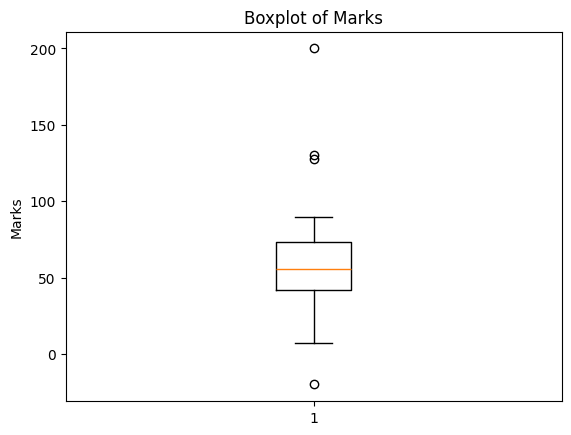

In [23]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.boxplot(df['Marks'])
plt.title('Boxplot of Marks')
plt.ylabel('Marks')
plt.show()


Text(0.5, 1.0, 'Histogram of Marks')

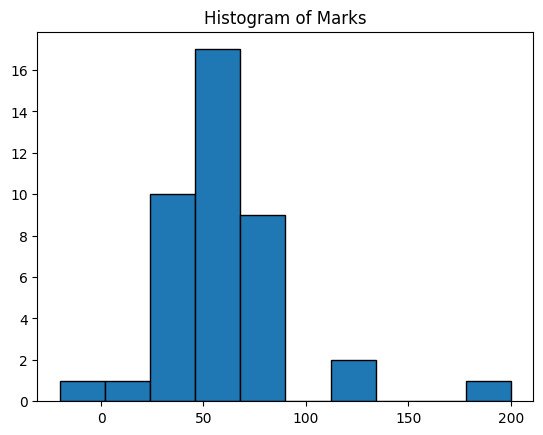

In [24]:
# visulaize the distribution of marks using histogram
plt.hist(df['Marks'], bins=10, edgecolor='black')
plt.title('Histogram of Marks')

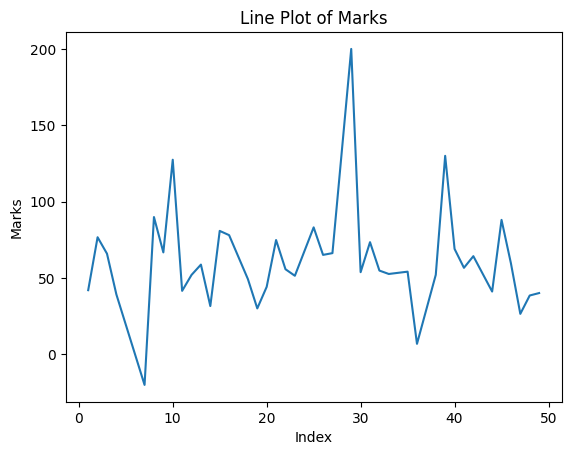

In [25]:
#line plot of marks
plt.plot(df['Marks'])
plt.title('Line Plot of Marks')
plt.xlabel('Index')
plt.ylabel('Marks')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_15676\775294441.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Admission']=='Yes']['Marks'], df[df['Admission']=='No']['Marks']], labels=['Admitted', 'Not Admitted'])


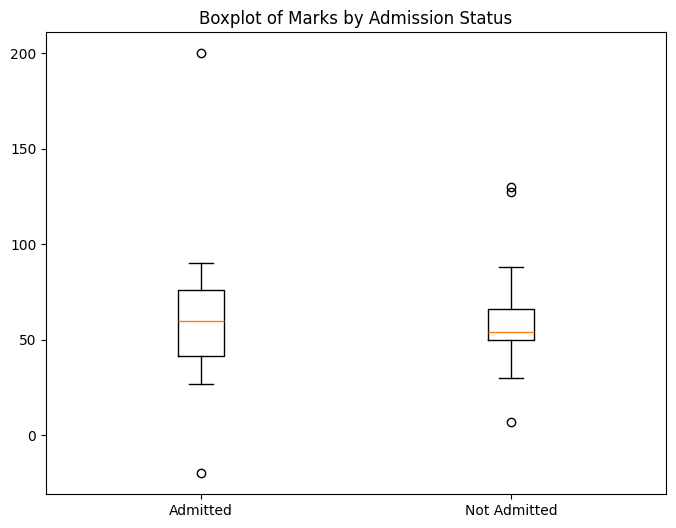

In [26]:
# compare marks and admission status using boxplot
plt.figure(figsize=(8,6))
plt.boxplot([df[df['Admission']=='Yes']['Marks'], df[df['Admission']=='No']['Marks']], labels=['Admitted', 'Not Admitted'])
plt.title('Boxplot of Marks by Admission Status')
plt.show()

In [18]:
arr = np.array([1,2,3,4,5,6,7])
mean_of_array = np.mean(arr)
mean_of_array

np.float64(4.0)

In [19]:
median_of_array = np.median(arr)
median_of_array

np.float64(4.0)

In [20]:
standard_deviation = np.std(arr)
standard_deviation

np.float64(2.0)

In [21]:
variance = np.var(arr)
variance

np.float64(4.0)

In [22]:
print("maximum number :" , np.max(arr))
print("minimum number :" , np.min(arr))
print("sum of array elements :" , np.sum(arr))
print("25th percentile :" , np.percentile(arr,25))
print("50th percentile :" , np.percentile(arr,50))
print("75th percentile :" , np.percentile(arr,75))


maximum number : 7
minimum number : 1
sum of array elements : 28
25th percentile : 2.5
50th percentile : 4.0
75th percentile : 5.5
